# 🤖 AI, CA3, Machine Learning 📚  

* **Name** : Parham 🖊  
* **Last Name** : Javan 📝  
* **SID** : 810800008 🆔

Libraries

In [258]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt





## 🧹 Data Preprocessing  
Implement all your preprocessing in this section, following the guidelines provided in the project documentation 📄.  

### 📥 Load Dataset  
In this subsection, you should load the dataset as a pandas dataframe 🐼.

In [259]:
# Step 1: Load the CSV file into a Pandas DataFrame
csv_file = 'hotels_in_europe.csv'
df = pd.read_csv(csv_file)

In [260]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7322 entries, 0 to 7321
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  7322 non-null   object 
 1   location              7322 non-null   object 
 2   price                 7322 non-null   object 
 3   rating                7129 non-null   float64
 4   quality               7169 non-null   object 
 5   review                7169 non-null   object 
 6   bed                   7299 non-null   object 
 7   size                  2454 non-null   object 
 8   distance_from_center  7322 non-null   float64
 9   room_type             7322 non-null   object 
 10  nights                7322 non-null   object 
 11  adults                7322 non-null   object 
 12  free_cancellation     583 non-null    object 
dtypes: float64(2), object(11)
memory usage: 743.8+ KB
None


### ➕ Additional Columns  
In this subsection, you should add some additional columns to the dataframe, according to the project documentation 📄.

In [261]:
print(df.nunique())

name                     949
location                  75
price                   2014
rating                    64
quality                   13
review                   729
bed                      162
size                     107
distance_from_center     137
room_type                426
nights                     5
adults                     5
free_cancellation          1
dtype: int64


In [262]:
from sklearn.preprocessing import LabelEncoder


In [263]:
# encode to numerical
df['room_type_encoded'] = df['room_type'].factorize()[0]
df['bed_encoded'] = df['bed'].factorize()[0]

# from sklearn.preprocessing import LabelEncoder
# df['location'] = LabelEncoder.fit_transform(df['location'])
# df['room_type'] = LabelEncoder.fit_transform(df['room_type'])


In [264]:
print(df['quality'].unique())

['Good' 'Very good' 'Fabulous' 'Superb' 'Review score' 'Exceptional' nan
 'Good 7.3' 'Superb 9.0' 'Fabulous 8.9' 'Fabulous 8.7' 'Exceptional 9.6'
 'Review score 6.4' 'Very good 8.1']


this block transfer some instances of quality to new quality and rating like Very good 8.1 to Very good and update rating to 8.1(rating usually nan)

In [265]:
# Function to process the quality column
def process_quality(row):
    if isinstance(row['quality'], str):
        parts = row['quality'].rsplit(' ', 1)  # Split from the right, max 1 split
        if len(parts) == 2 and parts[1].replace('.', '', 1).isdigit():
            # Update quality to text and rating to the number
            row['quality'] = parts[0]
            row['rating'] = float(parts[1])
    return row

# Apply the function to each row
df = df.apply(process_quality, axis=1)

In [266]:
df.head(4)

,name,location,price,rating,quality,review,bed,size,distance_from_center,room_type,nights,adults,free_cancellation,room_type_encoded,bed_encoded
0,WIT Hotel,"9th arr., Paris","IRR 7,951,542",7.1,Good,"3,300 reviews",1 double bed,20m²,1.9,Suite,1 night,1 adult,NaN,0,0
1,UCPA SPORT STATION HOSTEL PARIS,"19th arr., Paris","IRR 1,397,677",8.0,Very good,"5,921 reviews",1 single bed,NaN,4.6,Single Bed in 6-Bed Dormitory Room,1 night,1 adult,NaN,1,1
2,Timhotel Montmartre,"18th arr., Paris","IRR 7,569,083",8.3,Very good,"2,532 reviews",1 single bed,NaN,3.4,Comfort Single Room,1 night,1 adult,NaN,2,1
3,Hôtel Galileo Champs Elysées,"8th arr., Paris","IRR 6,447,737",8.6,Fabulous,"1,457 reviews",1 large double bed,NaN,4.2,Classic Room,1 night,1 adult,NaN,3,2


### 🛠 Handling Missing Values 💡
In this subsection, you are supposed to handle null and missing values, following regular techinuques, used in this context

In [267]:
df.isnull().sum()

name                       0
location                   0
price                      0
rating                   153
quality                  153
review                   153
bed                       23
size                    4868
distance_from_center       0
room_type                  0
nights                     0
adults                     0
free_cancellation       6739
room_type_encoded          0
bed_encoded                0
dtype: int64

In [268]:
# Remove Irrelevant Features:size and cancellation too much loss data data(more than half)
df.drop(columns=['size'], inplace=True)
df.drop(columns=['free_cancellation'], inplace=True)
# quality fabcricatable form rating
# df.drop(columns=['quality'], inplace=True)


i chose removing missing instances because they are not alot

In [269]:
#  removal , mean/median imputation, mode imputation
df = df.dropna()

# df['rating'].fillna(df['rating'].median(), inplace=True)

# df['rating'].fillna(df['rating'].mode(), inplace=True)


In [270]:
df.isnull().sum()

name                    0
location                0
price                   0
rating                  0
quality                 0
review                  0
bed                     0
distance_from_center    0
room_type               0
nights                  0
adults                  0
room_type_encoded       0
bed_encoded             0
dtype: int64

### 🧩 Manipulate Columns 🔢  
In this subsection, you should extract numerical values from columns and also convert categorical data to numerical values,as described in the project documentation 📄.

convert to numerical for price reviews , night , adults

In [271]:
# Function to extract numerical values from strings
def extract_number(column):
    return column.str.extract(r'([\d,\.]+)')[0].str.replace(',', '').astype(float)

# Apply the function to relevant columns
df['price'] = extract_number(df['price'])  # Convert to numeric
df['review'] = extract_number(df['review']).astype(int)  # Reviews as integer
df['nights'] = extract_number(df['nights']).astype(int)  # Nights as integer
df['adults'] = extract_number(df['adults']).astype(int)  # Adults as integer

In [272]:
df.head(4)

,name,location,price,rating,quality,review,bed,distance_from_center,room_type,nights,adults,room_type_encoded,bed_encoded
0,WIT Hotel,"9th arr., Paris",7951542.0,7.1,Good,3300,1 double bed,1.9,Suite,1,1,0,0
1,UCPA SPORT STATION HOSTEL PARIS,"19th arr., Paris",1397677.0,8.0,Very good,5921,1 single bed,4.6,Single Bed in 6-Bed Dormitory Room,1,1,1,1
2,Timhotel Montmartre,"18th arr., Paris",7569083.0,8.3,Very good,2532,1 single bed,3.4,Comfort Single Room,1,1,2,1
3,Hôtel Galileo Champs Elysées,"8th arr., Paris",6447737.0,8.6,Fabulous,1457,1 large double bed,4.2,Classic Room,1,1,3,2


add new column

In [273]:
df['price_per_night'] = df['price'] / df['nights']

### 🏷 Assigning Labels  
In this subsection, we want to assign labels to hotels 🏨, according to their price 💰.  
We have two labels:  
- **0** for hotels with a price less than a threshold 🟢.  
- **1** for those with higher prices 🔴.  

To determine the threshold, we use the median of prices 📊.  
In the first step, complete the following function. Then, you should use the `apply` method of pandas 🐼 to assign labels to each hotel.

In [274]:
# df['price_category'] = (df['price'] > df['price'].median()).astype(int)

In [275]:
# Define a function to assign labels based on the threshold
def assign_label(price, threshold):
    return 0 if price < threshold else 1

# Calculate the threshold (median of prices)
threshold = df['price'].median()

# Apply the function to the DataFrame
df['price_category'] = df['price'].apply(assign_label, threshold=threshold)

# Display the updated DataFrame
df.head(4)


,name,location,price,rating,quality,review,bed,distance_from_center,room_type,nights,adults,room_type_encoded,bed_encoded,price_per_night,price_category
0,WIT Hotel,"9th arr., Paris",7951542.0,7.1,Good,3300,1 double bed,1.9,Suite,1,1,0,0,7951542.0,0
1,UCPA SPORT STATION HOSTEL PARIS,"19th arr., Paris",1397677.0,8.0,Very good,5921,1 single bed,4.6,Single Bed in 6-Bed Dormitory Room,1,1,1,1,1397677.0,0
2,Timhotel Montmartre,"18th arr., Paris",7569083.0,8.3,Very good,2532,1 single bed,3.4,Comfort Single Room,1,1,2,1,7569083.0,0
3,Hôtel Galileo Champs Elysées,"8th arr., Paris",6447737.0,8.6,Fabulous,1457,1 large double bed,4.2,Classic Room,1,1,3,2,6447737.0,0


## 📊 Data Visualization  
Research and explore various data visualization techniques 🔍 to identify the best options for your project 🎯. Different approaches may be suitable for different aspects of your data 📈.

In [276]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7146 entries, 0 to 7321
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  7146 non-null   object 
 1   location              7146 non-null   object 
 2   price                 7146 non-null   float64
 3   rating                7146 non-null   float64
 4   quality               7146 non-null   object 
 5   review                7146 non-null   int32  
 6   bed                   7146 non-null   object 
 7   distance_from_center  7146 non-null   float64
 8   room_type             7146 non-null   object 
 9   nights                7146 non-null   int32  
 10  adults                7146 non-null   int32  
 11  room_type_encoded     7146 non-null   int64  
 12  bed_encoded           7146 non-null   int64  
 13  price_per_night       7146 non-null   float64
 14  price_category        7146 non-null   int64  
dtypes: float64(4), int32(3), i

In [277]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 7146 entries, 0 to 7321
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  7146 non-null   object 
 1   location              7146 non-null   object 
 2   price                 7146 non-null   float64
 3   rating                7146 non-null   float64
 4   quality               7146 non-null   object 
 5   review                7146 non-null   int32  
 6   bed                   7146 non-null   object 
 7   distance_from_center  7146 non-null   float64
 8   room_type             7146 non-null   object 
 9   nights                7146 non-null   int32  
 10  adults                7146 non-null   int32  
 11  room_type_encoded     7146 non-null   int64  
 12  bed_encoded           7146 non-null   int64  
 13  price_per_night       7146 non-null   float64
 14  price_category        7146 non-null   int64  
dtypes: float64(4), int32(3), i

name                     928
location                  75
price                   1976
rating                    64
quality                    6
review                   722
bed                      156
distance_from_center     136
room_type                422
nights                     5
adults                     5
room_type_encoded        422
bed_encoded              156
price_per_night         1994
price_category             2
dtype: int64


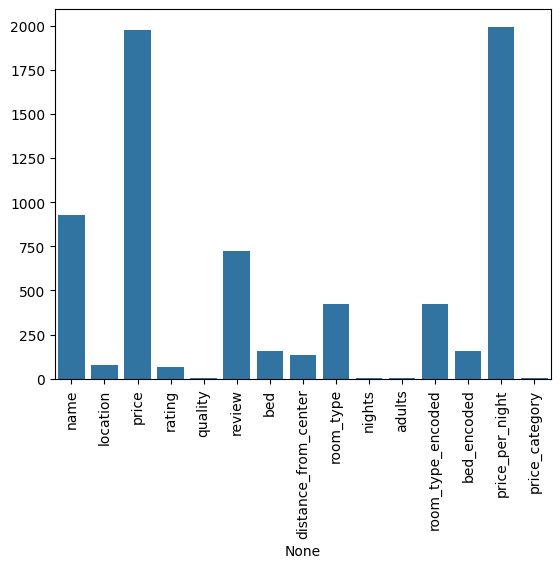

In [278]:
unique_counts = df.nunique()
print(df.nunique())
sns.barplot(x=unique_counts.index, y=unique_counts.values)
plt.xticks(rotation=90)
plt.show()


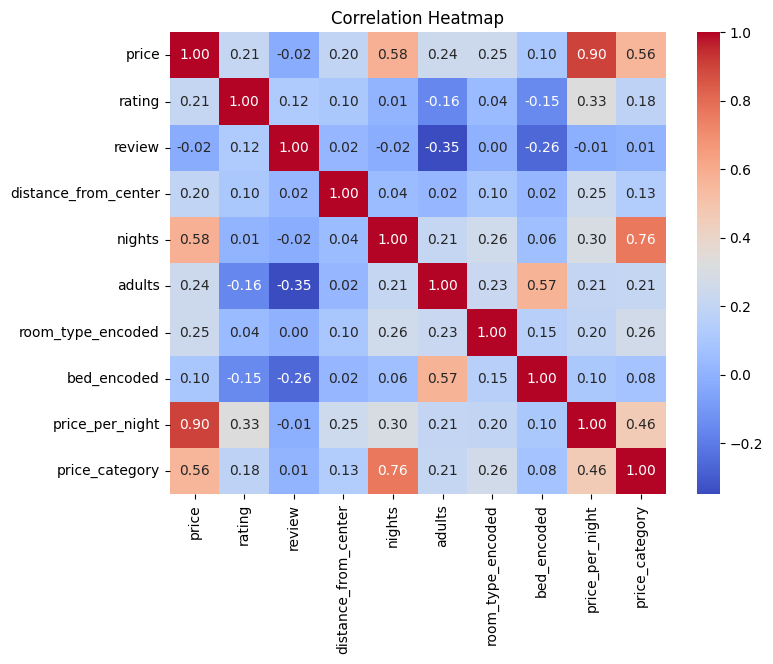

In [279]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Heatmap')
plt.show()

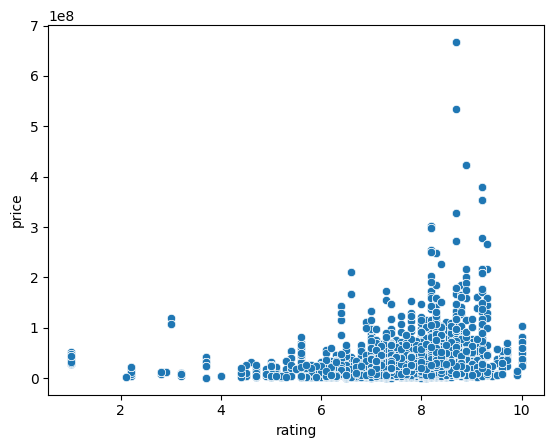

In [280]:
sns.scatterplot(x="rating", y="price", data=df)
plt.show()


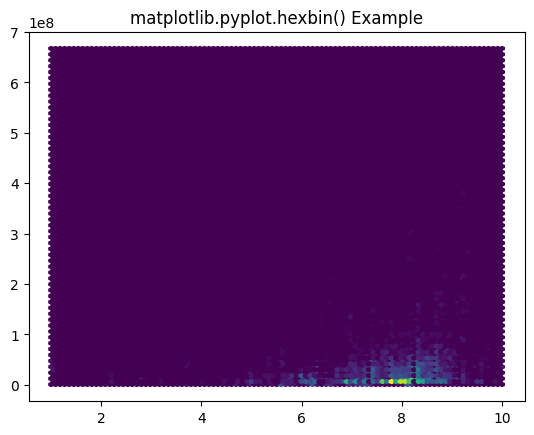

In [281]:
plt.hexbin(x="rating", y="price", data=df )  
plt.title('matplotlib.pyplot.hexbin() Example')  
plt.show() 

## 🏷 Classification  
In this section, we will go through the classification pipeline. We will deploy several machine learning models to classify hotels based on their price 💵. Finally, you will implement a boosting algorithm from scratch 🛠 and compare its performance with the library implementation 📚.

In [282]:
df.to_csv('modified.csv')

### 🔀 Train-Test Split  
You should divide the data into a training set and a test set. Use 20% of the data for testing and 80% for training 📊.

In [283]:
from sklearn.model_selection import train_test_split

# Select only numerical columns
categorical_df = df
df = df.select_dtypes(include=['number'] )

# X = df.drop(columns=['price_category'])
# y = df['price_category']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



X = df.drop(columns=['price', 'price_per_night' ,'price_category'])
y = df['price_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 🌐 Normalization  
One of the most important steps in the classification pipeline is normalization. You will be asked about the importance of this step ⚙️.

In [284]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 🚀 Deploying Sklearn Models  
In this subsection, you should use built-in models from the sklearn library for the classification task. Don't forget to show the complete classification report, including the confusion matrix, precision, recall, F1-score, and accuracy 📊. You will be asked about these metrics 📈.

In [285]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

#### 📉 Gaussian Naive Bayes

In [286]:
from sklearn.naive_bayes import GaussianNB

# Create a Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()

# Train the model
nb_classifier.fit(X_train, y_train)

# Predict the test set results
y_pred = nb_classifier.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Accuracy: 0.8566433566433567
Confusion Matrix:
 [[608  96]
 [109 617]]
Precision: 0.8568013562702748
Recall: 0.8566433566433567
F1 Score: 0.8566515591919797


In [287]:
predictions = nb_classifier.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       704
           1       0.87      0.85      0.86       726

    accuracy                           0.86      1430
   macro avg       0.86      0.86      0.86      1430
weighted avg       0.86      0.86      0.86      1430



#### 🌳 Decision Tree Classifier

Train the Decision Tree Model
Now, train the Decision Tree model using the training data.

In [288]:
# Initialize the DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Model Evaluation
After training the model, you can evaluate its performance on the test set.

In [289]:
# Predict on the test data
y_pred = dt_classifier.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.972027972027972
Confusion Matrix:
 [[686  18]
 [ 22 704]]
Precision: 0.9720451544011336
Recall: 0.972027972027972
F1 Score: 0.9720289570664415


Visualizing the Decision Tree
You can visualize the decision tree to understand the model better. This step very useful for understanding how the model is making decisions.

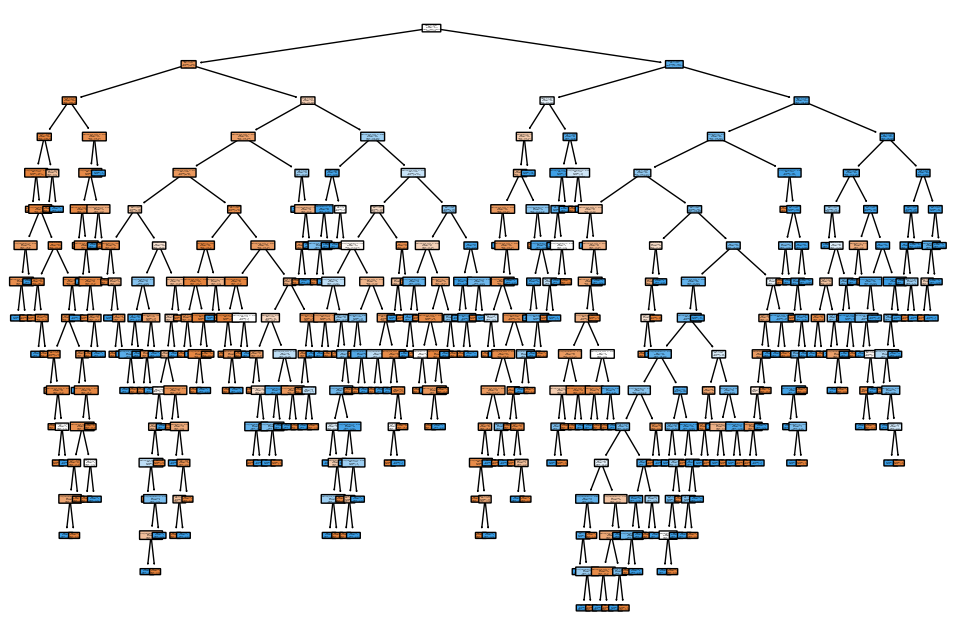

In [290]:
# Plot the tree
plt.figure(figsize=(12,8))
plot_tree(dt_classifier, feature_names=X.columns, class_names=['Cheap', 'Expensive'], filled=True, rounded=True)
plt.show()

Hyperparameter Tuning You can also optimize the performance of your decision tree by tuning hyperparameters like max_depth, min_samples_split, and min_samples_leaf.

In [291]:
# Example: using GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)


Best Hyperparameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}


Final Model Evaluation with Best Parameters
After finding the best parameters, you can refit the model and evaluate it again.

In [292]:
# Train the final model with the best parameters
best_dt_classifier = grid_search.best_estimator_

# Predict on the test set
y_pred_final = best_dt_classifier.predict(X_test)

# Evaluate the final model
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f'Final Accuracy: {final_accuracy}')
print(classification_report(y_test, y_pred_final))


Final Accuracy: 0.972027972027972
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       704
           1       0.98      0.97      0.97       726

    accuracy                           0.97      1430
   macro avg       0.97      0.97      0.97      1430
weighted avg       0.97      0.97      0.97      1430



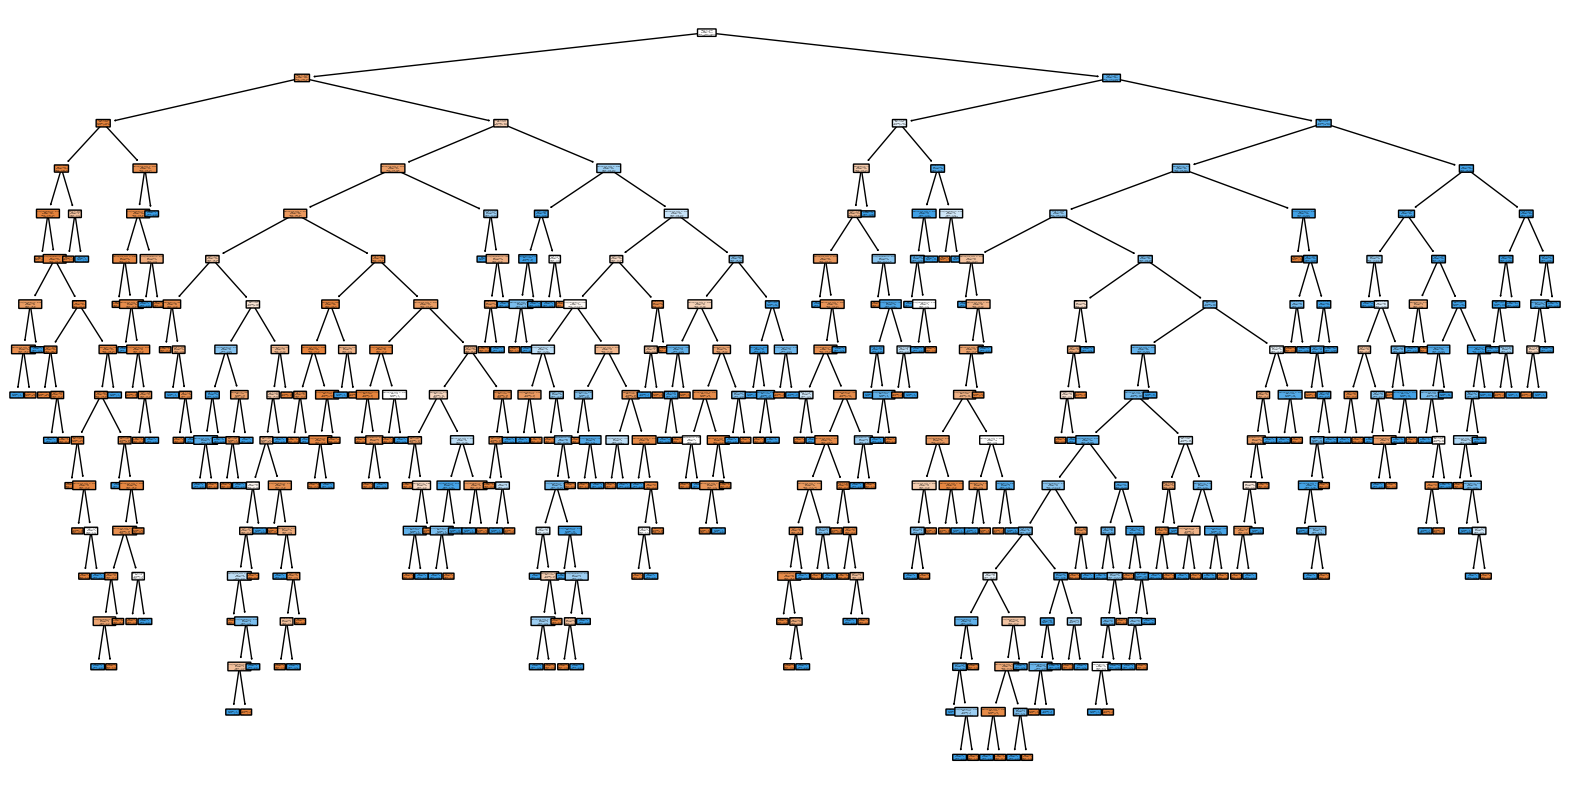

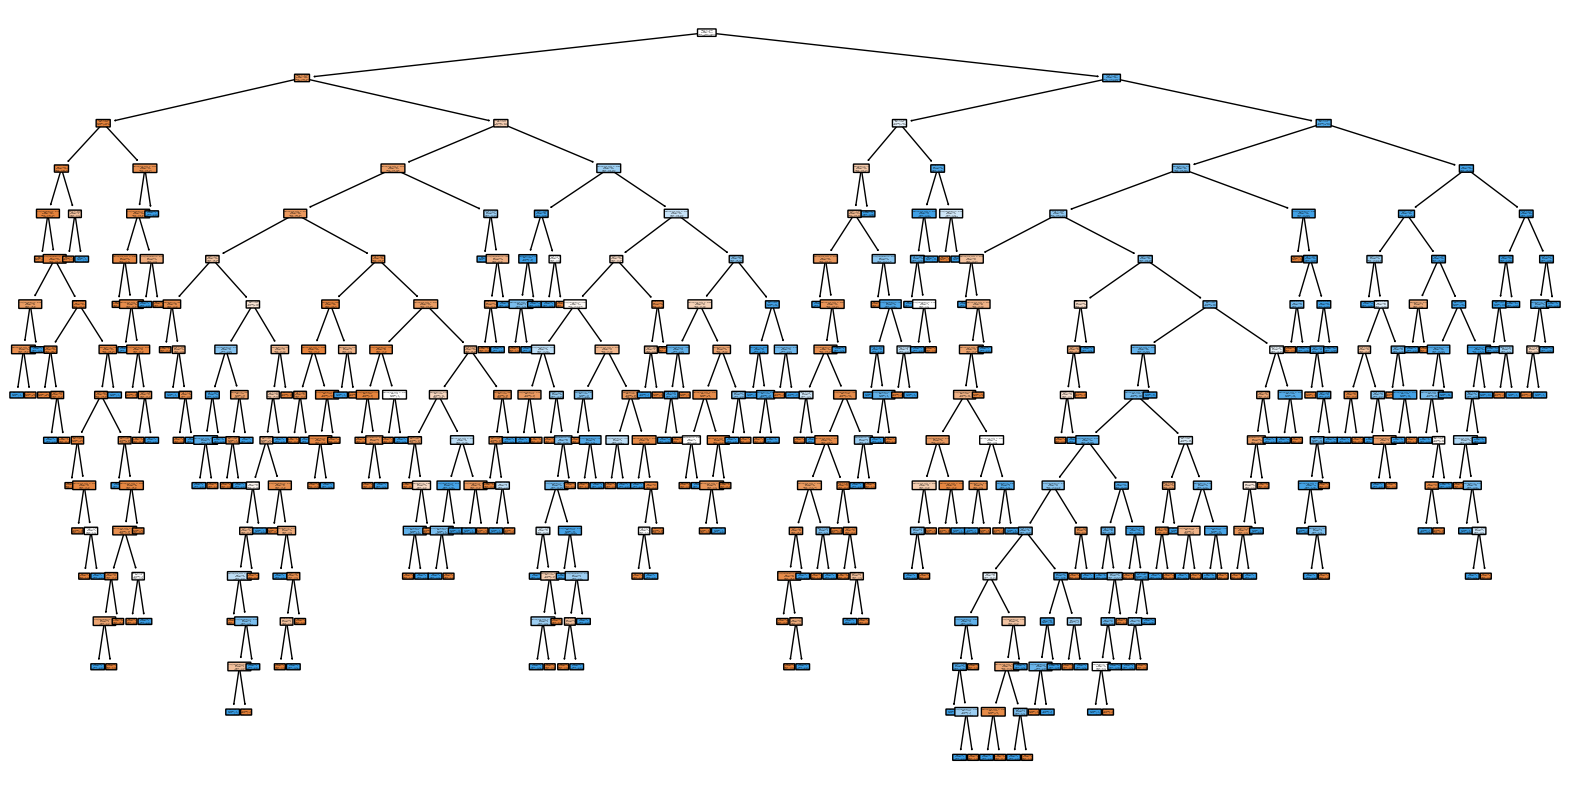

In [293]:
# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(best_dt_classifier, feature_names=X.columns, class_names=['Cheap', 'Expensive'], filled=True, rounded=True)
plt.show()

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(dt_classifier, feature_names=X.columns, class_names=['Cheap', 'Expensive'], filled=True, rounded=True)
plt.show()


#### 🌲🌳 Random Forest Classifier 

In [294]:
# Initialize the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_classifier.predict(X_test)


# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))
print('-----------------------------------')

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf}')
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9818181818181818
Confusion Matrix:
 [[690  14]
 [ 12 714]]
Precision: 0.9818211702827087
Recall: 0.9818181818181818
F1 Score: 0.9818177549155613
-----------------------------------
Random Forest Accuracy: 0.9818181818181818
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       704
           1       0.98      0.98      0.98       726

    accuracy                           0.98      1430
   macro avg       0.98      0.98      0.98      1430
weighted avg       0.98      0.98      0.98      1430



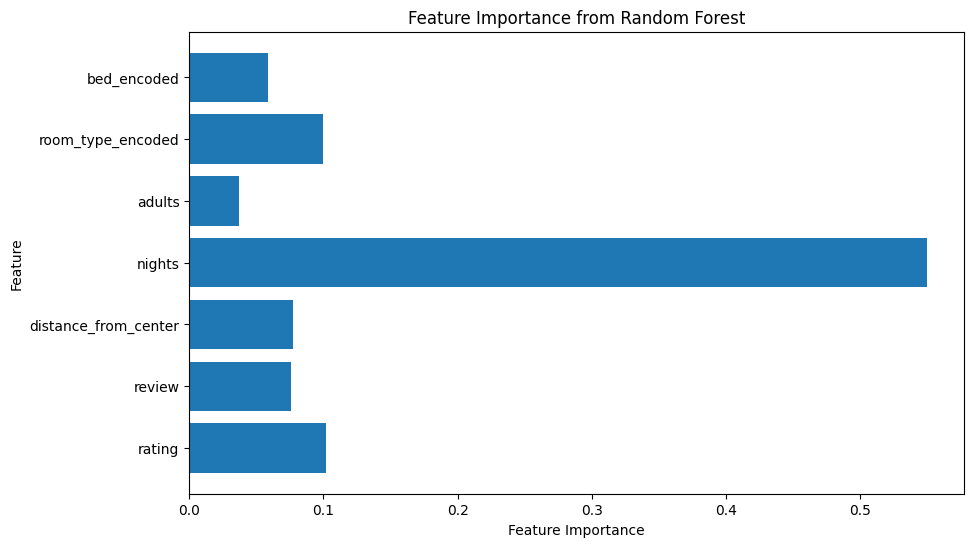

In [295]:
# Get feature importance from the trained model
feature_importances = rf_classifier.feature_importances_

# Create a bar plot for feature importance
import matplotlib.pyplot as plt

# Assuming X has the feature names
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest')
plt.show()


Hyperparameter Tuning with GridSearchCV
You can fine-tune the Random Forest model by adjusting hyperparameters like n_estimators, max_depth, and min_samples_split using GridSearchCV.

In [296]:
# Define hyperparameters to tune
param_grid_rf = {
    'n_estimators': [10, 50],  # Fewer trees
    'max_depth': [10, None],    # Less depth
    'min_samples_split': [2, 10],  # Fewer split options
    'min_samples_leaf': [1, 2],    # Fewer leaf options
    'bootstrap': [True],           # Only use bootstrap
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)

# Fit GridSearchCV
grid_search_rf.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", grid_search_rf.best_params_)

# Train the final model with the best parameters
best_rf_classifier = grid_search_rf.best_estimator_

# Predict on the test set
y_pred_rf_final = best_rf_classifier.predict(X_test)

# Evaluate the final model
final_accuracy_rf = accuracy_score(y_test, y_pred_rf_final)
print(f'Final Random Forest Accuracy: {final_accuracy_rf}')
print(classification_report(y_test, y_pred_rf_final))


Best Hyperparameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Final Random Forest Accuracy: 0.9783216783216783
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       704
           1       0.98      0.98      0.98       726

    accuracy                           0.98      1430
   macro avg       0.98      0.98      0.98      1430
weighted avg       0.98      0.98      0.98      1430



In [298]:
from sklearn.model_selection import RandomizedSearchCV
# Use RandomizedSearchCV instead of GridSearchCV
random_search_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, n_iter=10, cv=5, n_jobs=-1)
random_search_rf.fit(X_train, y_train)


# Define the parameter space for RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [10, 20, 30, None],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 5],    # Minimum samples required to be at a leaf node
    'bootstrap': [True, False]        # Whether bootstrap samples are used when building trees
}


# param_dist_rf = {
#     'n_estimators': [10, 50, 100, 200],        # Number of trees in the forest
#     'max_depth': [10, 20, 30, None],            # Max depth of each tree
#     'min_samples_split': [2, 5, 10],             # Min samples required to split a node
#     'min_samples_leaf': [1, 2, 4],               # Min samples required to be a leaf node
#     'bootstrap': [True, False],                  # Bootstrap sampling
#     'max_features': ['auto', 'sqrt', 'log2']    # Max features for each tree
# }

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,    # The hyperparameter space to sample from
    n_iter=10,                            # Number of random combinations to try
    cv=3,                                  # Number of folds for cross-validation
    n_jobs=-1,                             # Use all CPU cores
    random_state=42,                       # Set random seed for reproducibility
    verbose=1                              # Show progress during search
)

# Fit RandomizedSearchCV
random_search_rf.fit(X_train, y_train)

# Best hyperparameters found
print("Best Hyperparameters:", random_search_rf.best_params_)

# Train the final model with the best parameters
best_rf_classifier = random_search_rf.best_estimator_

# Predict on the test set
y_pred_rf_final = best_rf_classifier.predict(X_test)

# Evaluate the final model
final_accuracy_rf = accuracy_score(y_test, y_pred_rf_final)
print(f'Final Random Forest Accuracy: {final_accuracy_rf}')
print(classification_report(y_test, y_pred_rf_final))


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Hyperparameters: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}
Final Random Forest Accuracy: 0.9832167832167832
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       704
           1       0.98      0.98      0.98       726

    accuracy                           0.98      1430
   macro avg       0.98      0.98      0.98      1430
weighted avg       0.98      0.98      0.98      1430



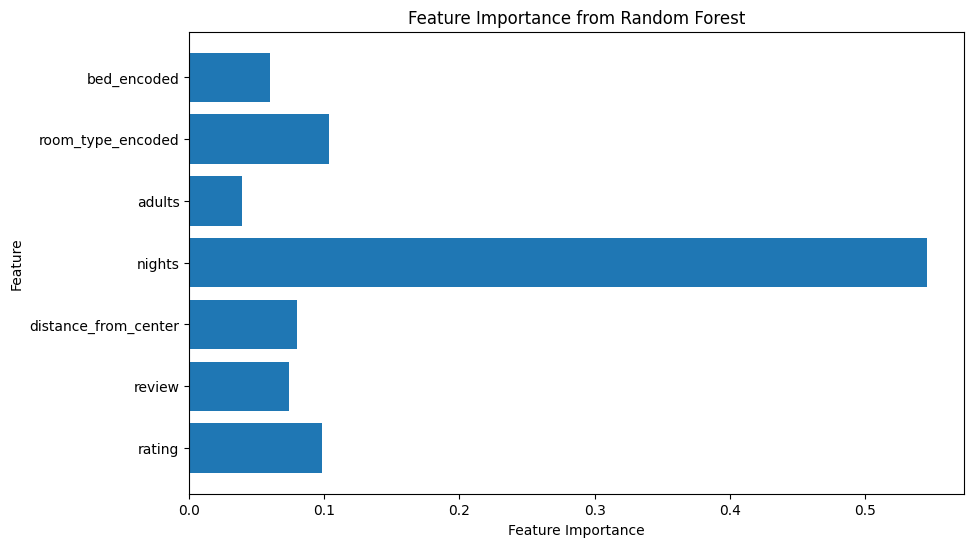

In [299]:
# Get feature importance from the trained model
feature_importances = best_rf_classifier.feature_importances_

# Create a bar plot for feature importance
import matplotlib.pyplot as plt

# Assuming X has the feature names
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest')
plt.show()


#### ⚡️ Adaptive Boosting

In [311]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
# Define a weak learner (Decision Tree with max depth of 1)
estimator = DecisionTreeClassifier(max_depth=1)

# Initialize AdaBoost with 50 estimators (you can tune this)
ada_boost_classifier = AdaBoostClassifier(estimator=estimator , 
                                          n_estimators=50, 
                                          random_state=42)

# Train the AdaBoost classifier
ada_boost_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ada = ada_boost_classifier.predict(X_test)

# Evaluate the model
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f'AdaBoost Accuracy: {accuracy_ada}')
print(classification_report(y_test, y_pred_ada))


AdaBoost Accuracy: 0.9193097014925373
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1052
           1       0.93      0.91      0.92      1092

    accuracy                           0.92      2144
   macro avg       0.92      0.92      0.92      2144
weighted avg       0.92      0.92      0.92      2144



c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [337]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for AdaBoost
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1, 10]
}

# Initialize GridSearchCV
grid_search_ada = GridSearchCV(AdaBoostClassifier(estimator=estimator,algorithm='SAMME', random_state=42), 
                               param_grid_ada, cv=5)

# Fit GridSearchCV
grid_search_ada.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", grid_search_ada.best_params_)

# Train final model with best parameters
best_ada_classifier = grid_search_ada.best_estimator_

# Predict and evaluate
y_pred_best_ada = best_ada_classifier.predict(X_test)
accuracy_best_ada = accuracy_score(y_test, y_pred_best_ada)
print(f'Best AdaBoost Accuracy: {accuracy_best_ada}')
print(classification_report(y_test, y_pred_best_ada))


Best Hyperparameters: {'learning_rate': 1, 'n_estimators': 200}
Best AdaBoost Accuracy: 0.9230410447761194
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1052
           1       0.93      0.92      0.92      1092

    accuracy                           0.92      2144
   macro avg       0.92      0.92      0.92      2144
weighted avg       0.92      0.92      0.92      2144



c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


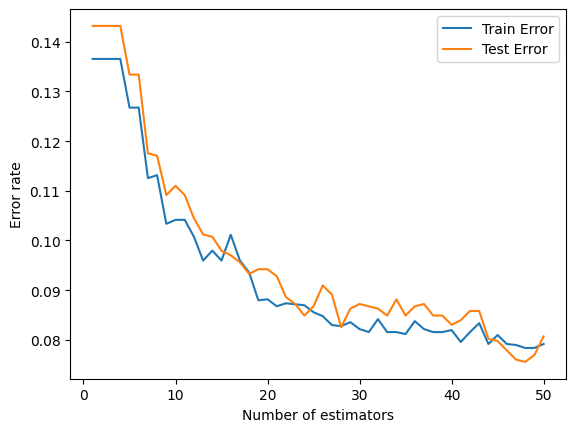

In [314]:
# Plot error rates during training
import matplotlib.pyplot as plt

train_errors = []
test_errors = []

for y_pred_train, y_pred_test in zip(ada_boost_classifier.staged_predict(X_train), 
                                      ada_boost_classifier.staged_predict(X_test)):
    train_errors.append(1 - accuracy_score(y_train, y_pred_train))
    test_errors.append(1 - accuracy_score(y_test, y_pred_test))

plt.plot(range(1, len(train_errors) + 1), train_errors, label='Train Error')
plt.plot(range(1, len(test_errors) + 1), test_errors, label='Test Error')
plt.xlabel('Number of estimators')
plt.ylabel('Error rate')
plt.legend()
plt.show()


#### ⚡️ XGBoost

In [316]:
import xgboost as xgb
# Initialize XGBoost classifier
xgb_classifier = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')

# Train the model
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {accuracy_xgb}')
print(classification_report(y_test, y_pred_xgb))



XGBoost Accuracy: 0.9832089552238806
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1052
           1       0.99      0.98      0.98      1092

    accuracy                           0.98      2144
   macro avg       0.98      0.98      0.98      2144
weighted avg       0.98      0.98      0.98      2144



In [321]:
# # Define the hyperparameter grid
# param_grid_xgb = {
#     'n_estimators': [50, 100, 200],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 6, 10],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0],
#     'gamma': [0, 0.1, 0.2],
# }

param_grid_xgb = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'learning_rate': [0.01, 0.1, 0.2],  # Learning rate (step size)
    'max_depth': [3, 6, 10],  # Max depth of the decision trees
    'min_child_weight': [1, 2, 5],  # Minimum number of samples required to form a leaf
    'colsample_bytree': [0.8, 1.0],  # Fraction of features to use for each tree
    'subsample': [0.8, 1.0],  # Fraction of training samples to use for each tree
    'gamma': [0, 0.1, 0.2],  # Minimum loss reduction required to make a further partition
}

#  Initialize XGBoost classifier
xgb_classifier = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(xgb_classifier, param_grid_xgb, n_iter=10, cv=3, random_state=42)

# Fit the model with RandomizedSearchCV
random_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:", random_search.best_params_)

# Train the final model with the best parameters
best_xgb_classifier = random_search.best_estimator_

# Make predictions and evaluate the model
y_pred_best_xgb = best_xgb_classifier.predict(X_test)
accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
print(f'Best XGBoost Accuracy: {accuracy_best_xgb}')
print(classification_report(y_test, y_pred_best_xgb))

Best Hyperparameters: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best XGBoost Accuracy: 0.9808768656716418
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1052
           1       0.99      0.98      0.98      1092

    accuracy                           0.98      2144
   macro avg       0.98      0.98      0.98      2144
weighted avg       0.98      0.98      0.98      2144



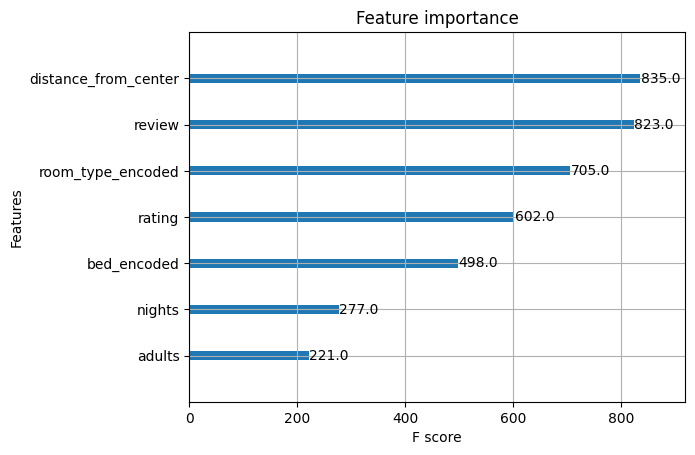

In [320]:
import matplotlib.pyplot as plt

# Plot the feature importance
xgb.plot_importance(best_xgb_classifier, importance_type='weight', max_num_features=10)
plt.show()


from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth': [3, 5, 10]}
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)


### 🛠 From Scratch  
In this subsection, you should implement the SAMME algorithm for adaptive boosting from scratch.Then you should deploy this boosting model and a base estimator, which is Gaussian Naive Bayes here, to classify hotels.

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.naive_bayes import GaussianNB
import numpy as np
class SimpleMultiClassBoosting(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=GaussianNB, n_estimators=50):
        self.base_estimator = base_estimator if base_estimator is not None else GaussianNB()
        self.n_estimators = n_estimators
        self.learners = []
        self.learner_weights = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.weights = (1/n_samples) * np.ones(n_samples, dtype=float) # initialize weights uniformly
        for _ in range(self.n_estimators):
            learner = GaussianNB() # instanciate model
            learner.fit(X, y, sample_weight=self.weights) # fit to samples, using weights
            pred = learner.predict(X) # predict the batch
            missClassified = pred != y # get index of misclassified samples
            # TODO : compute learner error rate according to SAMME algorithm
            # TODO : compute learner weight using SAMME algorithm
            # TODO : a classifier with error rate which is worse than random should be dropped
            # hint : error rate of untrained classifier : 1 - (1 / n_classes)

            # TODO : increase the weights of misclassified samples according to SAMME algorithm    
            self.weights /= np.sum(self.weights) # renormalize weights to make them sum up to 1  
            self.learners.append(learner)
            # TODO : store learner weight in self.learner_weights

    def predict(self, X):
        # note that X can contain multiple samples in shape of array, in which, each row corresponds to a query
        predictionsOfLearners = []
        for learner in self.learners:
            predictionsOfLearners.append(learner.predict(X)) # collect predictions from each learner
        # TODO : weighted vote for each sample's prediction across all learners, each learner's weight is stored in self.learner_weights
        # TODO : make final prediction by considering the label which has highest weighted vote
        

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.naive_bayes import GaussianNB
import numpy as np

class SimpleMultiClassBoosting(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=GaussianNB, n_estimators=50):
        self.base_estimator = base_estimator if base_estimator is not None else GaussianNB()
        self.n_estimators = n_estimators
        self.learners = []
        self.learner_weights = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        n_classes = len(np.unique(y))
        self.weights = (1 / n_samples) * np.ones(n_samples, dtype=float)  # initialize weights uniformly
        
        for _ in range(self.n_estimators):
            learner = clone(self.base_estimator)  # clone the base estimator to ensure it’s reinitialized each time
            learner.fit(X, y, sample_weight=self.weights)  # fit the learner using the sample weights
            pred = learner.predict(X)  # make predictions on the training set
            missClassified = pred != y  # identify misclassified samples
            
            # Compute the learner error rate
            error_rate = np.sum(self.weights * missClassified) / np.sum(self.weights)
            
            # If error rate is greater than 0.5, the model is worse than random; stop boosting
            if error_rate >= 0.5:
                break
            
            # Compute learner weight using SAMME algorithm
            learner_weight = 0.5 * np.log((1 - error_rate) / error_rate) + np.log(n_classes - 1)
            
            # Increase the weights of misclassified samples
            self.weights[missClassified] *= np.exp(learner_weight)
            
            # Normalize the weights
            self.weights /= np.sum(self.weights)
            
            # Append learner and its weight to the list
            self.learners.append(learner)
            self.learner_weights.append(learner_weight)

    def predict(self, X):
        # Collect predictions from each learner
        predictionsOfLearners = np.array([learner.predict(X) for learner in self.learners])
        
        # Compute weighted vote for each sample's prediction
        weighted_votes = np.zeros((predictionsOfLearners.shape[1], predictionsOfLearners.shape[0]))  # shape (n_samples, n_estimators)
        
        for idx, learner_weight in enumerate(self.learner_weights):
            weighted_votes += learner_weight * (predictionsOfLearners == idx)
        
        # Make final prediction by selecting the class with the highest weighted vote
        final_predictions = np.argmax(weighted_votes, axis=0)
        
        return final_predictions


In [329]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.naive_bayes import GaussianNB
import numpy as np

class SimpleMultiClassBoosting(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=GaussianNB, n_estimators=50):
        self.base_estimator = base_estimator if base_estimator is not None else GaussianNB()
        self.n_estimators = n_estimators
        self.learners = []
        self.learner_weights = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        n_classes = len(np.unique(y))
        self.weights = (1 / n_samples) * np.ones(n_samples, dtype=float)  # initialize weights uniformly
        
        for _ in range(self.n_estimators):
            learner = clone(self.base_estimator)  # clone the base estimator to ensure it’s reinitialized each time
            learner.fit(X, y, sample_weight=self.weights)  # fit the learner using the sample weights
            pred = learner.predict(X)  # make predictions on the training set
            missClassified = pred != y  # identify misclassified samples
            
            # Compute the learner error rate
            error_rate = np.sum(self.weights * missClassified) / np.sum(self.weights)
            
            # If error rate is greater than 0.5, the model is worse than random; stop boosting
            if error_rate >= 0.5:
                break
            
            # Compute learner weight using SAMME algorithm
            learner_weight = 0.5 * np.log((1 - error_rate) / error_rate) + np.log(n_classes - 1)
            
            # Increase the weights of misclassified samples
            self.weights[missClassified] *= np.exp(learner_weight)
            
            # Normalize the weights
            self.weights /= np.sum(self.weights)
            
            # Append learner and its weight to the list
            self.learners.append(learner)
            self.learner_weights.append(learner_weight)

    def predict(self, X):
        # Get predictions from each estimator
        predictionsOfLearners = np.array([learner.predict(X) for learner in self.learners])
        
        # Initialize weighted votes matrix (shape: n_classes x n_samples)
        weighted_votes = np.zeros((predictionsOfLearners.shape[1], predictionsOfLearners.shape[0]))  # shape (n_samples, n_estimators)
        
        for idx, learner_weight in enumerate(self.learner_weights):
            # Make sure the shape of the operation is correct
            weighted_votes += learner_weight * (predictionsOfLearners == idx).T  # Transpose to match the shape

        # Make final prediction by selecting the class with the highest weighted vote
        final_predictions = np.argmax(weighted_votes, axis=1)  # axis=1 for selecting class across all estimators

        return final_predictions



In [330]:
# Import necessary libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Initialize and train your custom boosting model
boosting_model = SimpleMultiClassBoosting(base_estimator=GaussianNB(), n_estimators=50)
boosting_model.fit(X_train, y_train)

# Predict on the test set
y_pred = boosting_model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))



Accuracy: 0.44449626865671643
              precision    recall  f1-score   support

           0       0.56      0.90      0.69      1052
           1       0.25      0.01      0.02      1092
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          16       0.00      0.00      0.00         0
          17       0.00      0.00      0.00         0

    accuracy                           0.44      2

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

new attempt


In [331]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.naive_bayes import GaussianNB
import numpy as np

class SimpleMultiClassBoosting(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=GaussianNB, n_estimators=50):
        self.base_estimator = base_estimator if base_estimator is not None else GaussianNB()
        self.n_estimators = n_estimators
        self.learners = []
        self.learner_weights = []

    def fit(self, X, y):
        n_samples, n_classes = X.shape[0], len(np.unique(y))
        self.weights = (1 / n_samples) * np.ones(n_samples, dtype=float)  # Initialize weights uniformly

        for _ in range(self.n_estimators):
            learner = self.base_estimator()  # Instantiate the base estimator
            learner.fit(X, y, sample_weight=self.weights)  # Fit the learner using the sample weights
            pred = learner.predict(X)  # Predictions on the training data
            
            # Compute the error rate
            missClassified = (pred != y)
            err_m = np.sum(self.weights * missClassified) / np.sum(self.weights)

            # Drop classifiers with error >= 1 - (1 / n_classes) (too high to be useful)
            if err_m >= 1 - (1 / n_classes):
                break
            
            # Compute the learner's weight
            alpha_m = np.log((1 - err_m) / err_m) + np.log(n_classes - 1)

            # Update sample weights
            self.weights *= np.exp(alpha_m * missClassified)
            self.weights /= np.sum(self.weights)  # Renormalize the weights
            
            # Store the learner and its weight
            self.learners.append(learner)
            self.learner_weights.append(alpha_m)

    def predict(self, X):
        # Collect predictions from all learners
        predictions_of_learners = np.array([learner.predict(X) for learner in self.learners])

        # Weighted vote for each sample
        weighted_votes = np.zeros((X.shape[0], len(np.unique(predictions_of_learners))))
        for i, alpha_m in enumerate(self.learner_weights):
            for j, pred in enumerate(predictions_of_learners[i]):
                weighted_votes[j, pred] += alpha_m

        # Final prediction: Take the class with the highest weighted vote
        return np.argmax(weighted_votes, axis=1)


In [336]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# Train SAMME implementation
samme_boost = SimpleMultiClassBoosting(n_estimators=50)
samme_boost.fit(X_train, y_train)
y_pred_custom = samme_boost.predict(X)

# Train scikit-learn's AdaBoostClassifier with SAMME
ada_boost = AdaBoostClassifier(n_estimators=50, algorithm='SAMME', random_state=42)
ada_boost.fit(X_train, y_train)
y_pred_sklearn = ada_boost.predict(X)

# Compare accuracies
print("Custom SAMME Accuracy:", accuracy_score(y, y_pred_custom))
print("Scikit-learn AdaBoost Accuracy:", accuracy_score(y, y_pred_sklearn))



Custom SAMME Accuracy: 0.8670584942625245
Scikit-learn AdaBoost Accuracy: 0.9121186677861741
